<a href="https://colab.research.google.com/github/Geon0904/Geon0904/blob/main/data-analysis/top-youtube-analysis" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of Factors Influencing the Top 1000 YouTubers by Subscriber Count

## Importing the Dataset


In [16]:
# Import required library
import pandas as pd

# Set the file path
file_path = '/content/drive/MyDrive/데이터분석/topSubscribed.csv'

# Create a DataFrame
df = pd.read_csv(file_path)

# Preview the results
print(df)

     Rank             Youtube Channel  Subscribers      Video Views  \
0       1                    T-Series  234,000,000  212,900,271,553   
1       2              YouTube Movies  161,000,000                0   
2       3  Cocomelon - Nursery Rhymes  152,000,000  149,084,178,448   
3       4                   SET India  150,000,000  137,828,094,104   
4       5                     MrBeast  128,000,000   21,549,128,785   
..    ...                         ...          ...              ...   
995   996                     XO TEAM   11,500,000   11,471,384,709   
996   997         Nirahua Music World   11,500,000    5,997,717,755   
997   998                     YtCrash   11,400,000        3,825,084   
998   999                   Painzeiro   11,400,000    2,143,444,281   
999  1000                   Oum Walid   11,400,000    2,480,064,722   

    Video Count          Category  Started  
0        18,515             Music     2006  
1             0  Film & Animation     2015  
2           

## 	Data Preprocessing

### Dropping Unnecessary Columns

In [17]:
### Dropping Unnecessary Columns
df.drop(columns=['Youtube Channel'], inplace=True)
print(f'After Dropping Unnecessary Columns, verify the data frame: \n{df}')

After Dropping Unnecessary Columns, verify the data frame: 
     Rank  Subscribers      Video Views Video Count          Category  Started
0       1  234,000,000  212,900,271,553      18,515             Music     2006
1       2  161,000,000                0           0  Film & Animation     2015
2       3  152,000,000  149,084,178,448         846         Education     2006
3       4  150,000,000  137,828,094,104     103,200             Shows     2006
4       5  128,000,000   21,549,128,785         733     Entertainment     2012
..    ...          ...              ...         ...               ...      ...
995   996   11,500,000   11,471,384,709       2,679    People & Blogs     2021
996   997   11,500,000    5,997,717,755         788             Music     2014
997   998   11,400,000        3,825,084           1         Education     2015
998   999   11,400,000    2,143,444,281         946    People & Blogs     2015
999  1000   11,400,000    2,480,064,722       1,598    People & Blogs  

### Handling Missing Values

In [18]:
### Checking the Number of Missing Values in Each Column
num_nulls = df.isnull().sum()
print(f'Number of Missing Values per Column: \n{num_nulls}')

Number of Missing Values per Column: 
Rank           0
Subscribers    0
Video Views    0
Video Count    0
Category       0
Started        0
dtype: int64


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Rank         1000 non-null   int64 
 1   Subscribers  1000 non-null   object
 2   Video Views  1000 non-null   object
 3   Video Count  1000 non-null   object
 4   Category     1000 non-null   object
 5   Started      1000 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 47.0+ KB


### Removing Commas and Converting to Integers

In [20]:
df1 = df.iloc[:,:]
print(df1)

     Rank  Subscribers      Video Views Video Count          Category  Started
0       1  234,000,000  212,900,271,553      18,515             Music     2006
1       2  161,000,000                0           0  Film & Animation     2015
2       3  152,000,000  149,084,178,448         846         Education     2006
3       4  150,000,000  137,828,094,104     103,200             Shows     2006
4       5  128,000,000   21,549,128,785         733     Entertainment     2012
..    ...          ...              ...         ...               ...      ...
995   996   11,500,000   11,471,384,709       2,679    People & Blogs     2021
996   997   11,500,000    5,997,717,755         788             Music     2014
997   998   11,400,000        3,825,084           1         Education     2015
998   999   11,400,000    2,143,444,281         946    People & Blogs     2015
999  1000   11,400,000    2,480,064,722       1,598    People & Blogs     2015

[1000 rows x 6 columns]


In [21]:
### The column contains numeric values but is stored as an object. First, remove the commas (,)

# Subscribers
df1.loc[:, 'Subscribers'] = df1.loc[:, 'Subscribers'].str.replace(',','',regex=True)

# Video Views
df1.loc[:, 'Video Views'] = df1.loc[:, 'Video Views'].str.replace(',','',regex=True)

# Video Count
df1.loc[:, 'Video Count'] = df1.loc[:, 'Video Count'].str.replace(',','',regex=True)

# df.info()

print(df1)

     Rank Subscribers   Video Views Video Count          Category  Started
0       1   234000000  212900271553       18515             Music     2006
1       2   161000000             0           0  Film & Animation     2015
2       3   152000000  149084178448         846         Education     2006
3       4   150000000  137828094104      103200             Shows     2006
4       5   128000000   21549128785         733     Entertainment     2012
..    ...         ...           ...         ...               ...      ...
995   996    11500000   11471384709        2679    People & Blogs     2021
996   997    11500000    5997717755         788             Music     2014
997   998    11400000       3825084           1         Education     2015
998   999    11400000    2143444281         946    People & Blogs     2015
999  1000    11400000    2480064722        1598    People & Blogs     2015

[1000 rows x 6 columns]


In [22]:
### Now convert the object type to integer.

# Subscribers (Obj -> int)
df1['Subscribers'] = pd.to_numeric(df1['Subscribers'], errors='coerce')

# Video Views (Obj -> int)
df1['Video Views'] = pd.to_numeric(df1['Video Views'], errors='coerce')

# Video Count (Obj -> int)
df1['Video Count'] = pd.to_numeric(df1['Video Count'], errors='coerce')

print(df1)

     Rank  Subscribers   Video Views  Video Count          Category  Started
0       1    234000000  212900271553        18515             Music     2006
1       2    161000000             0            0  Film & Animation     2015
2       3    152000000  149084178448          846         Education     2006
3       4    150000000  137828094104       103200             Shows     2006
4       5    128000000   21549128785          733     Entertainment     2012
..    ...          ...           ...          ...               ...      ...
995   996     11500000   11471384709         2679    People & Blogs     2021
996   997     11500000    5997717755          788             Music     2014
997   998     11400000       3825084            1         Education     2015
998   999     11400000    2143444281          946    People & Blogs     2015
999  1000     11400000    2480064722         1598    People & Blogs     2015

[1000 rows x 6 columns]


In [23]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Rank         1000 non-null   int64 
 1   Subscribers  1000 non-null   int64 
 2   Video Views  1000 non-null   int64 
 3   Video Count  1000 non-null   int64 
 4   Category     1000 non-null   object
 5   Started      1000 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 47.0+ KB


### Outlier Detection and Treatment

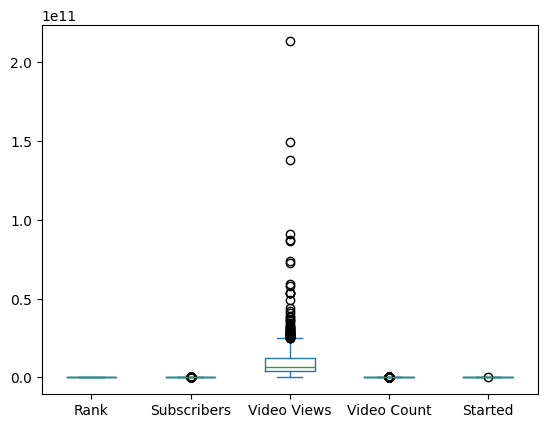

In [24]:
### Visualizing the Presence of Outliers Using a Boxplot

# Import required library
import matplotlib.pyplot as plt

# Visualizing
df1.plot(kind='box')
plt.show()

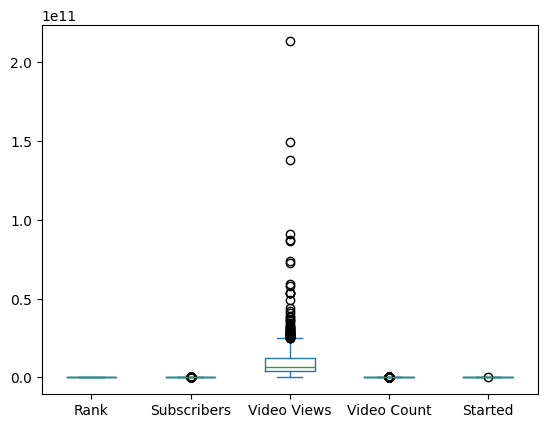

In [25]:
# Outlier Handling Based on IQR
Q1 = df1['Video Views'].quantile(0.25)
Q3 = df1['Video Views'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df1['Video Views'] >= lower_bound) & (df1['Video Views'] <= upper_bound)]

# Visualizing
df1.plot(kind='box')
plt.show()

## Exploratory Data Analysis (EDA)

In [26]:
### Import required library
import seaborn as sns

### Relationship Between Subscribers and Views

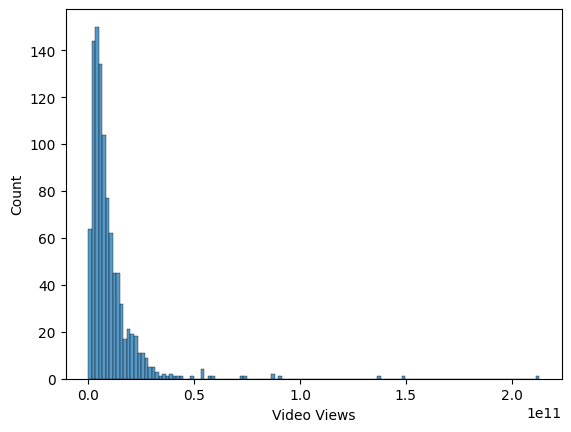

In [27]:
### Visualizing the Video Views Column

"""
### Video Views
"""

sns.histplot(data=df1, x='Video Views')
plt.show()

In [28]:
### Correlation Analysis
df_corr = df1.loc[:,['Subscribers', 'Video Views']].corr()
print(f'Correlation coefficient between Subscribers and Video Views : \n{df_corr}')

Correlation coefficient between Subscribers and Video Views : 
             Subscribers  Video Views
Subscribers     1.000000     0.753648
Video Views     0.753648     1.000000


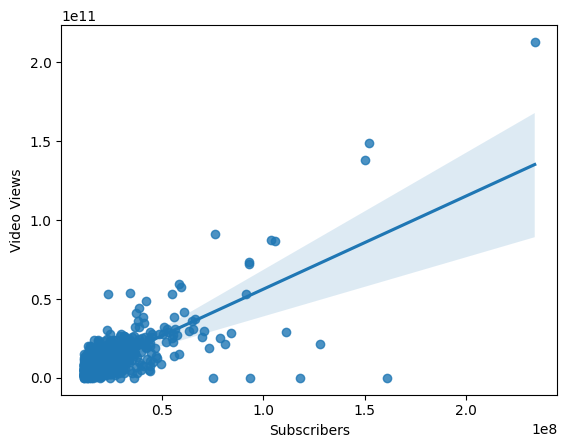

In [29]:
### Visualizing the Relationship Between Subscribers and Video Views
sns.regplot(data=df1, x='Subscribers', y='Video Views')
plt.show()

### Relationship Between Subscribers and Video Count

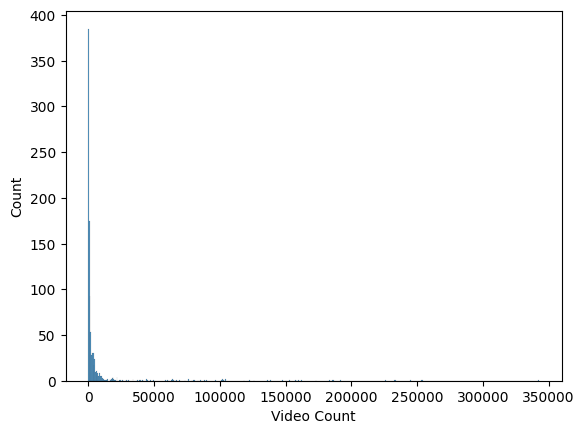

In [30]:
### Checking the Distribution of the Video Count Column

"""
### Video Count
"""

sns.histplot(data=df1, x='Video Count')
plt.show()

In [31]:
### Correlation Analysis
df_corr = df1.loc[:, ['Subscribers', 'Video Count']].corr()
print(f'Correlation coefficient between Subscribers and Video Count : \n{df_corr}')

Correlation coefficient between Subscribers and Video Count : 
             Subscribers  Video Count
Subscribers     1.000000     0.064661
Video Count     0.064661     1.000000


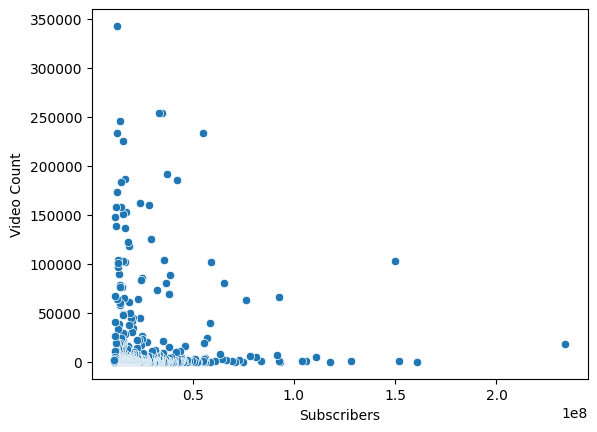

In [32]:
### Visualizing the Relationship Between Subscribers and Video Count
sns.scatterplot(data=df1, x='Subscribers', y='Video Count')
plt.show()

### Relationship Between Subscribers and Channel Start Year

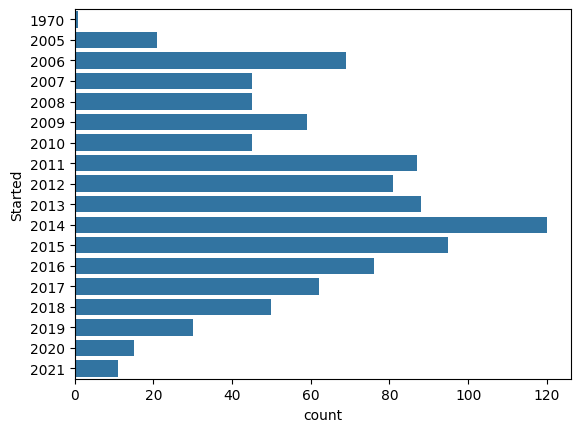

In [33]:
### Visualizing the Distribution of the 'Started' Column

"""
### Started
"""

sns.countplot(data=df1, y='Started')
plt.show()

In [34]:
### correaltion anaysis
df_corr = df1.loc[:,['Subscribers', 'Started']].corr()
print(f'Correlation coefficient between Subscribers and Started : \n{df_corr}')

Correlation coefficient between Subscribers and Started : 
             Subscribers   Started
Subscribers     1.000000 -0.135162
Started        -0.135162  1.000000


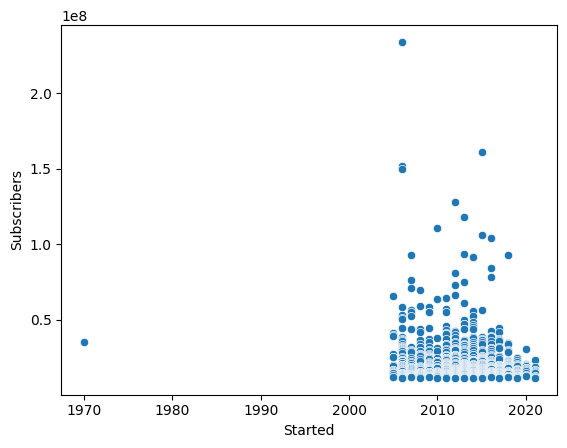

In [35]:
### Visualizing the Relationship Between Subscribers and Start Year
sns.scatterplot(data=df1,  x='Started', y='Subscribers')
plt.show()

###  Visualizing the Category Column

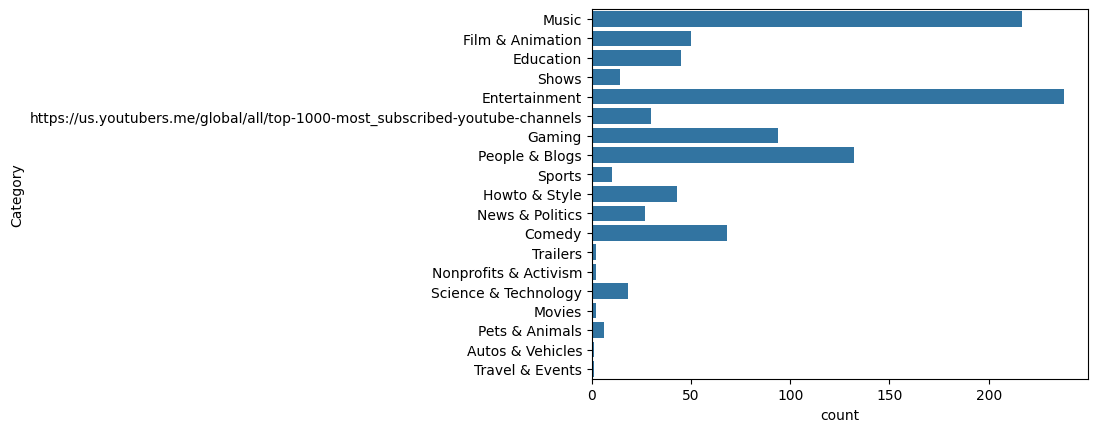

In [36]:

"""
### Category : YouTube Content Theme
"""

sns.countplot(data=df1, y='Category')
plt.show()

### Relationship Between Views and Video Count

In [39]:
### correaltion anaysis
df_corr = df1.loc[:,['Video Views', 'Video Count']].corr()
print(f'Correlation Coefficient Between Video Views and Video Count : \n{df_corr}')

Correlation Coefficient Between Video Views and Video Count : 
             Video Views  Video Count
Video Views     1.000000     0.151196
Video Count     0.151196     1.000000


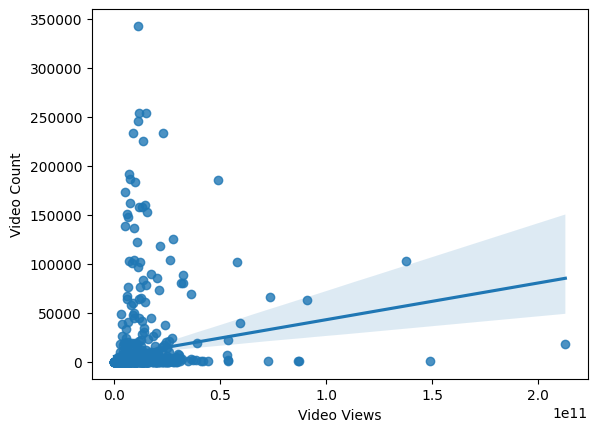

In [40]:
### Visualizing the Relationship Between Video Views and Video Count
sns.regplot(data=df1, x='Video Views', y='Video Count')
plt.show()

### Relationship Between Views and Channel Start Year

In [41]:
### correlation analysis
df_corr = df1.loc[:,['Video Views', 'Started']].corr()
print(f'Correlation Coefficient Between Video Views and Start Year: \n{df_corr}')

Correlation Coefficient Between Video Views and Start Year: 
             Video Views   Started
Video Views     1.000000 -0.157634
Started        -0.157634  1.000000


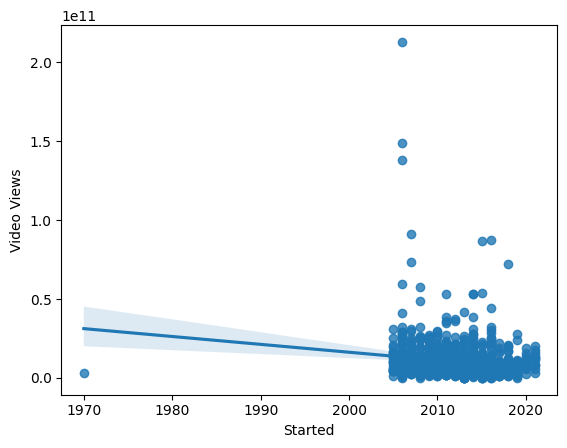

In [42]:
### Visualizing the Relationship Between Video Views and Start Year
sns.regplot(data=df1, x='Started', y='Video Views')
plt.show()

## Conclusion and Insights

In [ ]:
"""
In conclusion, we found a clear positive correlation between video views and the number of subscribers — channels with higher views tend to have more subscribers.
Additionally, we observed that among the top 1,000 most-subscribed YouTube channels, the majority of videos fall into the "Entertainment," "Music," and "People & Blogs" categories.

## Tree-Based Regression Modeling

### Train-Test Split for Modeling

In [44]:
### Creating Training and Testing Data with a 75:25 Split

# Import necessary functions
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# Create X_data (feature variables)
X_data = df1.drop(columns=['Rank', 'Subscribers', 'Category', 'Started', 'Video Count'])
print(f'X_data preview : \n{X_data}')

print('-'*80)

# Create y_data (target variable)
y_data = df1.loc[:, 'Subscribers']
print(f'y_data preview : \n{y_data}')

print('-'*80)

# Add constant term (intercept) for regression
X_data = sm.add_constant(X_data)

# Build OLS regression model
model = sm.OLS(y_data, X_data)
results = model.fit()
print(results.summary())


# Split data into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X_data,
                                                    y_data,
                                                    test_size=0.25,
                                                    random_state=0)

X_data preview : 
      Video Views
0    212900271553
1               0
2    149084178448
3    137828094104
4     21549128785
..            ...
995   11471384709
996    5997717755
997       3825084
998    2143444281
999    2480064722

[1000 rows x 1 columns]
--------------------------------------------------------------------------------
y_data preview : 
0      234000000
1      161000000
2      152000000
3      150000000
4      128000000
         ...    
995     11500000
996     11500000
997     11400000
998     11400000
999     11400000
Name: Subscribers, Length: 1000, dtype: int64
--------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:            Subscribers   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     1312.
Date:       

In [45]:
X_data.info()
y_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   const        1000 non-null   float64
 1   Video Views  1000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 15.8 KB
<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Subscribers
Non-Null Count  Dtype
--------------  -----
1000 non-null   int64
dtypes: int64(1)
memory usage: 7.9 KB


In [46]:
### Subscribers
y = (0.001*X_data) + (1.195e+07)
print(y)

            const   Video Views
0    1.195000e+07  2.248503e+08
1    1.195000e+07  1.195000e+07
2    1.195000e+07  1.610342e+08
3    1.195000e+07  1.497781e+08
4    1.195000e+07  3.349913e+07
..            ...           ...
995  1.195000e+07  2.342138e+07
996  1.195000e+07  1.794772e+07
997  1.195000e+07  1.195383e+07
998  1.195000e+07  1.409344e+07
999  1.195000e+07  1.443006e+07

[1000 rows x 2 columns]


### Subscriber Count Prediction Using Decision Tree Regression

#### Generating the Best Model

In [47]:
### Model Optimization

# Import necessary functions
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Create a base Decision Tree Regressor
base_dt = DecisionTreeRegressor(random_state=0)

# Define the parameter grid for optimization (max_depth from 3 to 10)
depth = np.arange(3,11)
params = {'max_depth':depth}

# Create a K-Fold cross-validator (10 splits, shuffled)
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

# Set up the grid search with cross-validation
grid_dt = GridSearchCV(
    estimator=base_dt,
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=kfold
)

# Train the model using grid search
grid_dt.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=DecisionTreeRegressor(random_state=0),
             param_grid={'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='neg_mean_squared_error')

In [48]:
### Check the Best Hyperparameters
print(grid_dt.best_params_)

{'max_depth': np.int64(3)}


In [49]:
### Build the Best Model
from sklearn.tree import DecisionTreeRegressor
best_dt = DecisionTreeRegressor(max_depth=3, random_state=0)

#### Training the Best Model

In [50]:
best_dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=0)

#### Visualizing Training Results

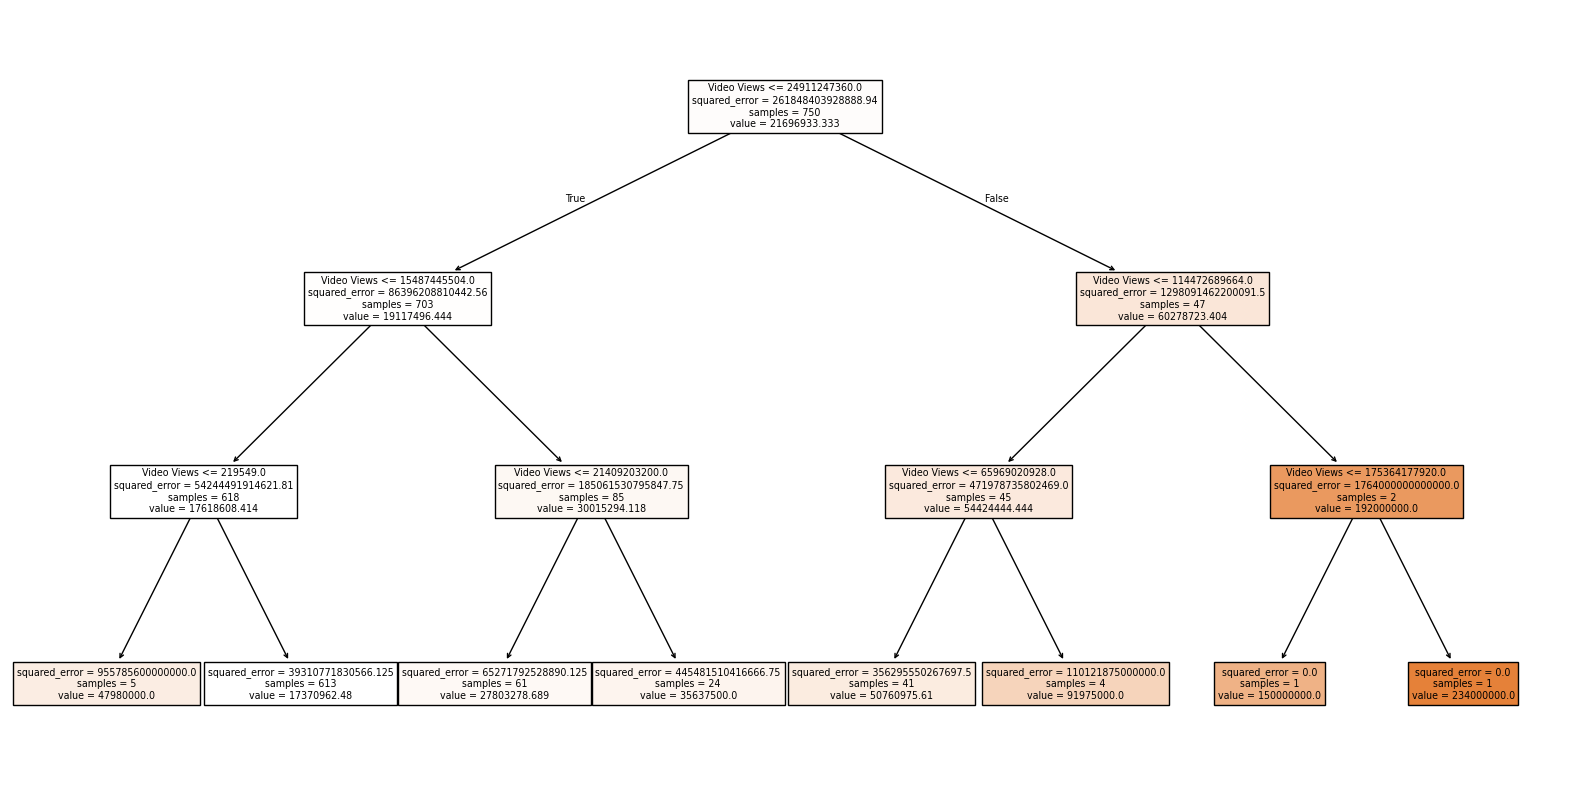

In [51]:
# Import visualization functions
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size for the tree plot
plt.figure(figsize=(20,10))

# Generate and display the decision tree plot (limited to depth=3 for readability)
plot_tree(best_dt, max_depth=3, feature_names=X_train.columns, filled=True)
plt.show()

#### Predicting on the Test Set

In [52]:
pred_test = best_dt.predict(X_test)

#### Evaluating the Best Model

In [53]:
# Import required function
from sklearn.metrics import mean_squared_error as mse

# Evaluate model performance on the test dataset
mse_test = mse(y_test, pred_test)

# Display the result
print(f'Model performance on test data (MSE) : {mse_test}')

Model performance on test data (MSE) : 148013428512803.72


In [54]:
### Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse_test)
print(f'Root Mean Squared Error on test data : {rmse}')

Root Mean Squared Error on test data : 12166076.95655439


### Subscriber Count Prediction Using XGBoost Regression

In [55]:
# Import necessary library
from xgboost import XGBRegressor

# Create a base model to be optimized
base_xgb = XGBRegressor(random_state=0)

# Define the hyperparameter grid for tuning
#depth = np.arange(3,11)
params = {'n_estimators':[100, 200, 300, 400, 500],
          'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
          'max_depth':[3, 4, 5, 6, 7]}

# Set up cross-validation strategy
kfold = KFold(n_splits=10, shuffle=True, random_state=0)

# Create a grid search model for hyperparameter tuning
grid_xgb = GridSearchCV(
    estimator=base_xgb,
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=kfold
)

# Train the grid search model on the training set
grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    inte...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=0, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
                         'max_depth': [3, 4, 5, 6, 7],
                         'n_estimators': [100, 200, 300, 400, 500]},
             scoring='neg_mean_squared_error')

In [56]:
### Check the Best Hyperparameters
print(grid_xgb.best_params_)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}


In [57]:
### Build the Best Model
best_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3,
    random_state=0
)

#### Training the Best Model

In [58]:
best_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=0, ...)

#### Predicting on the Test Set

In [59]:
pred_test = best_xgb.predict(X_test)

#### Evaluating the Best Model

In [60]:
# Evaluate model performance on the test dataset
mse_test = mse(y_test, pred_test)

# Display the test MSE result
print(f'Mean Squared Error on test data : {mse_test}')

Mean Squared Error on test data : 159474568396800.0


In [61]:
### Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse_test)
print(f'Root Mean Squared Error on test data : {rmse}')

Root Mean Squared Error on test data : 12628324.053365117


# Summary and Results of Linear Regression Model

In [ ]:
The R-squared value ranges from 0 to 1 and indicates how well the model explains the variability of the target variable.
A value closer to 1 suggests that the model's predictions closely align with the actual values.

An R-squared of 0.568 means that approximately 56.8% of the variance in the target variable (Subscribers) is explained by the model.
This suggests that the independent variables used are moderately effective at predicting subscriber count.

Strengths:
- The model captures more than half of the variation in the data, which can be considered a meaningful level of explanatory power.

- There is likely a significant relationship between the predictors and the target variable.

Limitations:
- The model fails to explain the remaining 43.2% of the variance, which may be due to omitted variables or noise in the data.

- This could suggest underfitting, where the model lacks complexity to capture the full pattern.

- Important predictors might be missing, or the relationships could be non-linear.

In [62]:
### Subscribers
y = (0.001*X_data) + (1.195e+07)
print(y)



The most common video categories among the top 1,000 YouTubers by subscriber count are "Entertainment," "Music,"
and "People & Blogs," which appear significantly more frequently than others.

SyntaxError: invalid syntax (<ipython-input-62-57c8f33e0a41>, line 7)